<a href="https://colab.research.google.com/github/Asmaaz2002/Asmaaz2002/blob/main/Diabetes%20Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1) استيراد المكتبات الأساسية
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# 2) تحميل الداتا مباشرة من رابط جاهز (ما يحتاج رفع ملف)
url = "https://raw.githubusercontent.com/mezkymy/diabetes-prediction/main/diabetes_prediction_dataset.csv"
df = pd.read_csv(url)

# 3) عرض أول 5 صفوف للتأكد
df.head()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [2]:
# معلومات عن الأعمدة وأنواع البيانات
df.info()

# إحصائيات وصفية للمتغيرات العددية
df.describe()

# التحقق من القيم الناقصة
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [3]:
# 1) فصل الـ features عن الـ target
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# 2) تحديد الأعمدة العددية والـ categorical
numeric_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
categorical_features = ['gender', 'smoking_history', 'hypertension', 'heart_disease']

numeric_features, categorical_features


(['age', 'bmi', 'HbA1c_level', 'blood_glucose_level'],
 ['gender', 'smoking_history', 'hypertension', 'heart_disease'])

In [4]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Transformer للأعمدة العددية
numeric_transformer = StandardScaler()

# Transformer للأعمدة الفئوية (categorical)
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# دمجهم في ColumnTransformer واحد
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

len(X_train), len(X_test)


(80000, 20000)

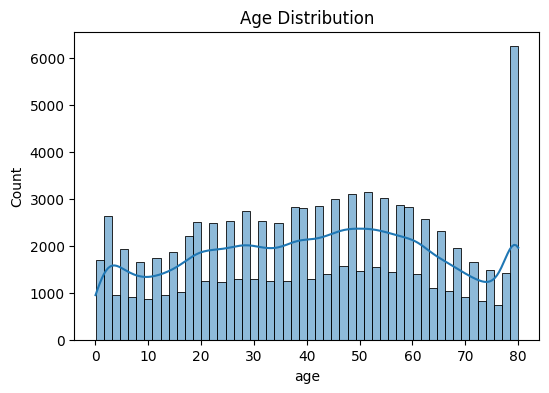

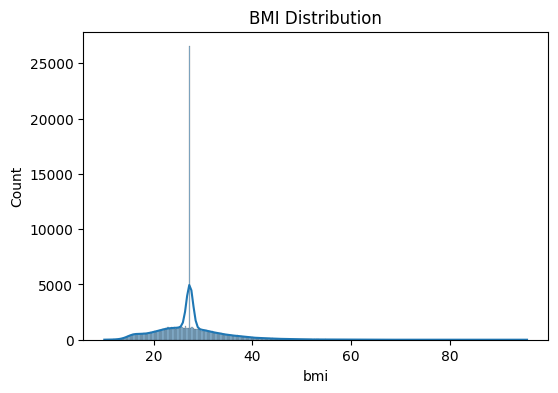

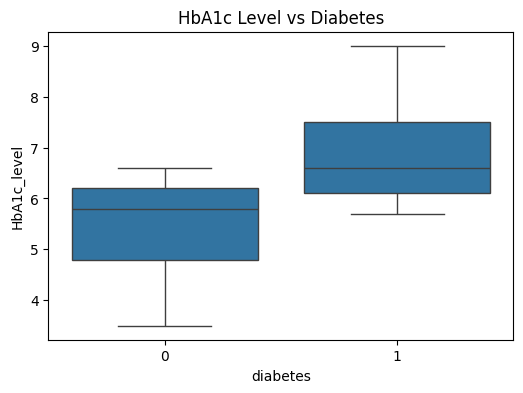

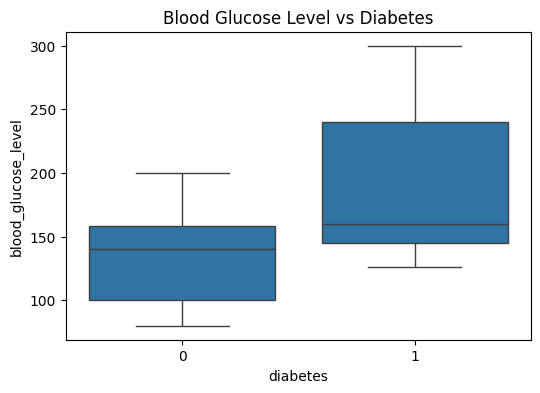

In [6]:
# توزيع العمر
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

# توزيع BMI
plt.figure(figsize=(6,4))
sns.histplot(df['bmi'], kde=True)
plt.title('BMI Distribution')
plt.show()

# مقارنة HbA1c بين مرضى السكر وغيرهم
plt.figure(figsize=(6,4))
sns.boxplot(x='diabetes', y='HbA1c_level', data=df)
plt.title('HbA1c Level vs Diabetes')
plt.show()

# مقارنة blood_glucose_level بين مرضى السكر وغيرهم
plt.figure(figsize=(6,4))
sns.boxplot(x='diabetes', y='blood_glucose_level', data=df)
plt.title('Blood Glucose Level vs Diabetes')
plt.show()


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_reg_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))


Accuracy: 0.9605
Precision: 0.8593996840442338
Recall: 0.64
F1-score: 0.7336480107889414


In [8]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

print("Decision Tree Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))


Decision Tree Results:
Accuracy: 0.9507
Precision: 0.6998880179171333
Recall: 0.7352941176470589
F1-score: 0.7171543316121629


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))


Random Forest Results:
Accuracy: 0.97
Precision: 0.94
Recall: 0.6911764705882353
F1-score: 0.7966101694915254


In [10]:
svm_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', SVC())
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

print("SVM Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))


SVM Results:
Accuracy: 0.96495
Precision: 0.9770773638968482
Recall: 0.601764705882353
F1-score: 0.7448125227520932


In [11]:
import pandas as pd

results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm)
    ]
}

df_results = pd.DataFrame(results)
df_results


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.96050,0.859400,0.640000,0.733648
1,Decision Tree,0.95070,0.699888,0.735294,0.717154
2,Random Forest,0.97000,0.940000,0.691176,0.796610
3,SVM,0.96495,0.977077,0.601765,0.744813


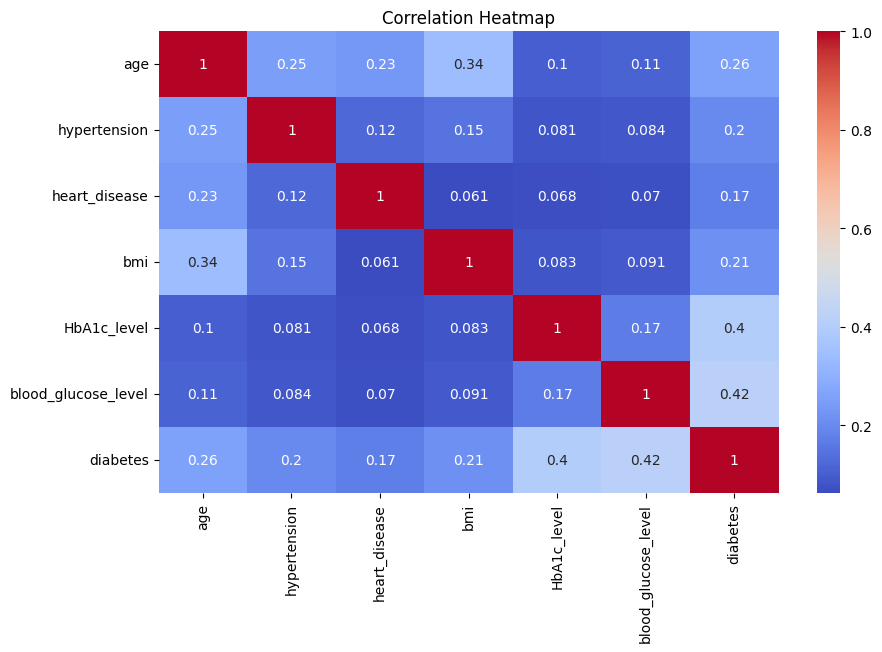

In [12]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5]
}

rf_grid = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(rf_grid, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

y_pred_gs = grid_search.predict(X_test)

print("GridSearch RF Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_gs))
print("Precision:", precision_score(y_test, y_pred_gs))
print("Recall:", recall_score(y_test, y_pred_gs))
print("F1-score:", f1_score(y_test, y_pred_gs))


Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}
GridSearch RF Results:
Accuracy: 0.97235
Precision: 1.0
Recall: 0.6747058823529412
F1-score: 0.8057604495960661
